**Week 2**

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sold_data = pd.read_csv('sold.csv')

/var/folders/mf/9m6y4nlx41z0kjyljz4sn3tc0000gn/T/ipykernel_26066/343568724.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: OriginatingSystemName, 4: OriginatingSystemSubName, 5: ListAgentEmail, 6: latfilled, 7: lonfilled, 8: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  sold_data = pd.read_csv('sold.csv')


Row count before Residential Filter (includes all PropertyType's): 591191

Row count AFTER Residential Filter: 397261

In [3]:
sold_data.shape

(397261, 84)

--**EDA**--

**Missing Value Analysis**: Identify which columns have a high percentage of missing values 

In [4]:
missing_counts = sold_data.isna().sum()

missing_pct = (missing_counts / len(sold_data)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

missing_summary["90pct_missing"] = missing_summary["missing_pct"] > 90

missing_summary = missing_summary.sort_values(by="missing_pct", ascending=False)

missing_summary.head(10)

,missing_count,missing_pct,90pct_missing
CoveredSpaces,397261,100.000000,True
MiddleOrJuniorSchoolDistrict,397261,100.000000,True
TaxAnnualAmount,397261,100.000000,True
ElementarySchoolDistrict,397261,100.000000,True
TaxYear,397261,100.000000,True
AboveGradeFinishedArea,397261,100.000000,True
FireplacesTotal,397261,100.000000,True
BusinessType,397261,100.000000,True
WaterfrontYN,397013,99.937573,True
BelowGradeFinishedArea,394971,99.423553,True


**Numeric Distribution Review**: What are the distributions of key numeric fields? 

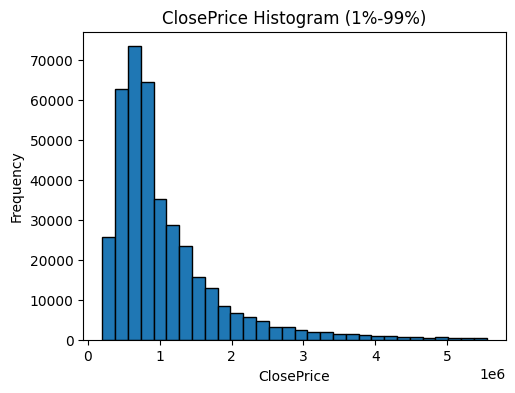

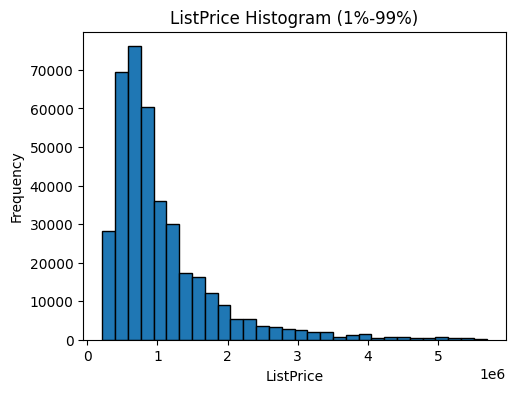

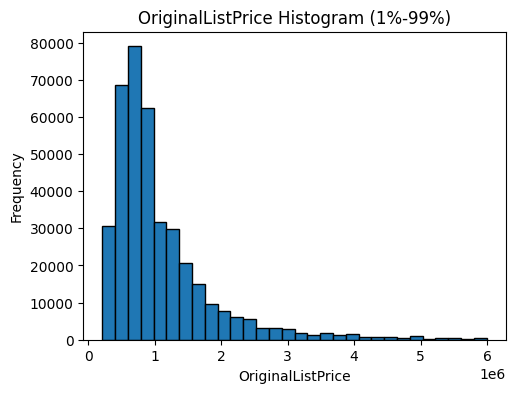

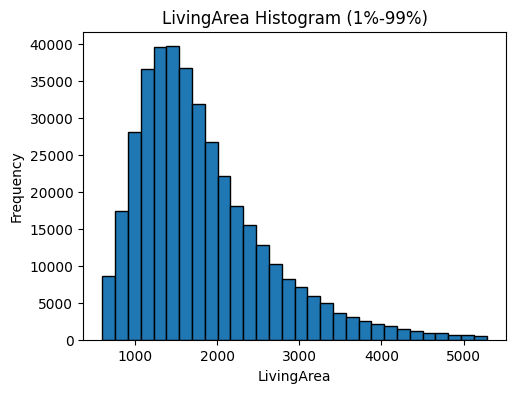

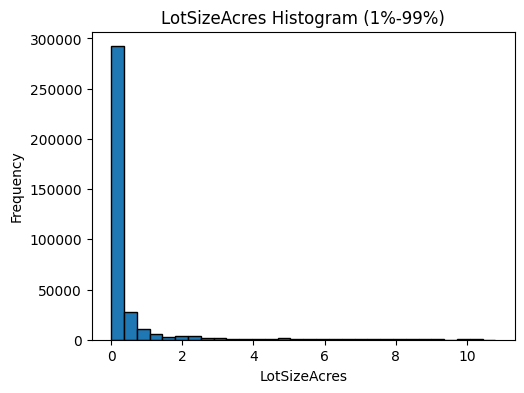

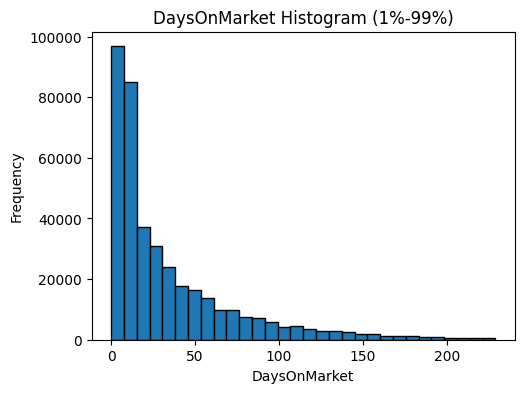

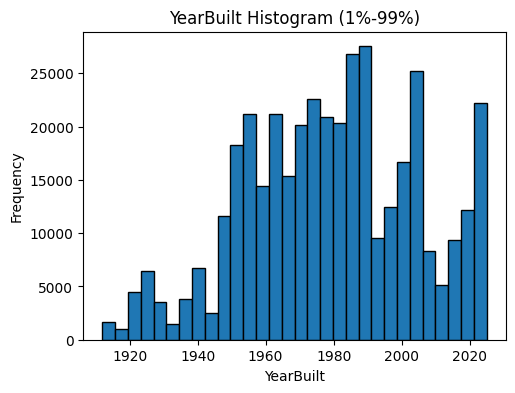

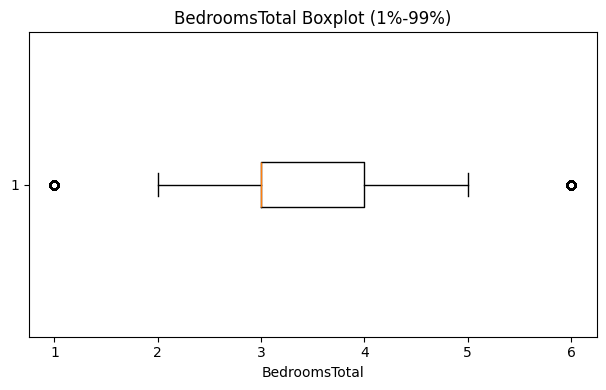

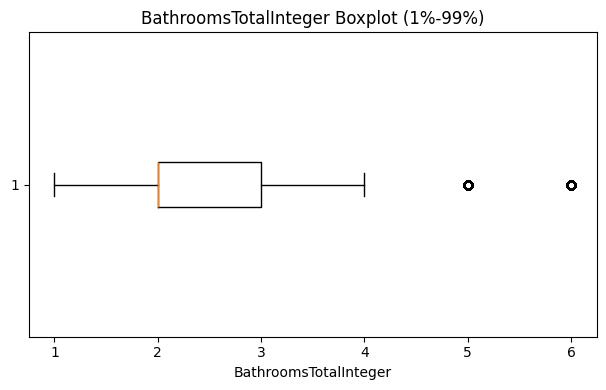

In [5]:
# HISTOGRAM PLOTTING 
cols_hist = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "DaysOnMarket", "YearBuilt"
]

for col in cols_hist:
    data = sold_data[col]

    # Missing values handling
    missing_count = data.isna().sum()

    # Drop NA values for visualization purposes
    x = data.dropna()

    # Handle extreme outliers by trimming data to range from 1st to 99th percentile
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)

    trimmed = x[(x >= lower) & (x <= upper)]

    outlier_count = len(x) - len(trimmed)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(trimmed, bins=30, edgecolor="black")
    plt.title(f"{col} Histogram (1%-99%)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

# BOXPLOT PLOTTING
cols_box = ["BedroomsTotal", "BathroomsTotalInteger"]

for col in cols_box:
    data = sold_data[col]

    # Missing values handling
    missing_count = data.isna().sum()

    # Drop NA values for visualization purposes
    x = data.dropna()

    # Handle extreme outliers by trimming data to range from 1st to 99th percentile
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)

    trimmed = x[(x >= lower) & (x <= upper)]

    outlier_count = len(x) - len(trimmed)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,2)
    plt.boxplot(trimmed, vert=False)
    plt.title(f"{col} Boxplot (1%-99%)")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

**Percentile Statistics**

In [6]:
column_percentile = []
outlier_dict = {}

cols = ["ClosePrice", "ListPrice", 
    "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "DaysOnMarket", "YearBuilt", 
    "BedroomsTotal", "BathroomsTotalInteger"]

for col in cols:
    data = sold_data[col].dropna()

    percentiles = data.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

    Q1 = percentiles.loc[0.25]
    Q3 = percentiles.loc[0.75]
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_dict[col] = outliers

    percentages = {
        "column": col,
        "1%": percentiles.loc[0.01],
        "5%": percentiles.loc[0.05],
        "25%": percentiles.loc[0.25],
        "50%": percentiles.loc[0.50],
        "75%": percentiles.loc[0.75],
        "95%": percentiles.loc[0.95],
        "99%": percentiles.loc[0.99],
        "outlier_count": len(outliers)
    }

    column_percentile.append(percentages)

column_distribution = pd.DataFrame(column_percentile)
column_distribution.head()

,column,1%,5%,25%,50%,75%,95%,99%,outlier_count
0,ClosePrice,202316.0,340000.00,575000.00,820000.0000,1.300000e+06,2.850000e+06,5.550000e+06,29383
1,ListPrice,214900.0,346000.00,575000.00,815000.0000,1.295000e+06,2.850000e+06,5.695000e+06,29553
2,OriginalListPrice,210000.0,349900.00,585000.00,825000.0000,1.299000e+06,2.899000e+06,5.995000e+06,30839
3,LivingArea,604.0,839.00,1247.00,1641.0000,2.217000e+03,3.558000e+03,5.280000e+03,17527
4,LotSizeAcres,0.0,0.03,0.12,0.1663,2.723000e-01,2.809700e+00,1.079932e+01,56935


Median and Average Close Prices

In [7]:
median_close = sold_data["ClosePrice"].median()
mean_close = sold_data["ClosePrice"].mean()

print("Median Close Price:", median_close)
print("Average Close Price:", mean_close)

Median Close Price: 820000.0
Average Close Price: 1186331.2366068736


Days on the Market Distribution

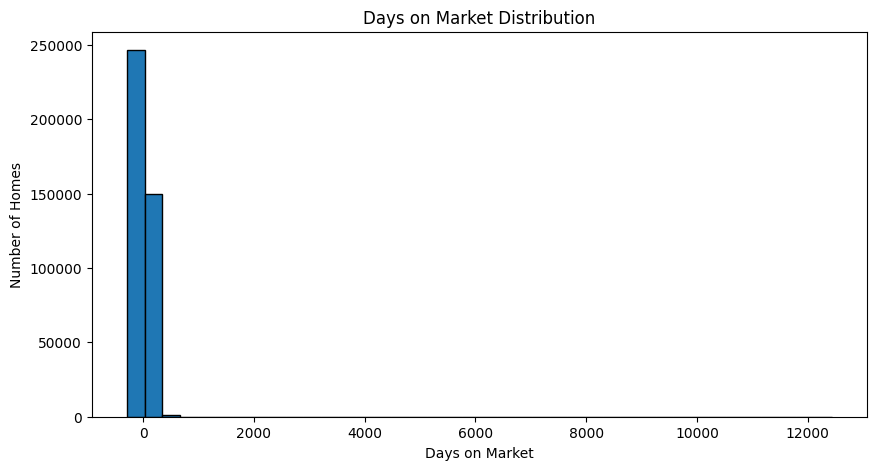

In [8]:
dom = sold_data["DaysOnMarket"].dropna()

plt.figure(figsize=(10,5))
plt.hist(dom, bins=40, edgecolor="black")
plt.title("Days on Market Distribution")
plt.xlabel("Days on Market")
plt.ylabel("Number of Homes")
plt.show()

Percentage of homes sold above vs. below list price

In [9]:
valid_prices = sold_data.dropna(subset=["ClosePrice", "ListPrice"])

above = (valid_prices["ClosePrice"] > valid_prices["ListPrice"]).mean() * 100
below = (valid_prices["ClosePrice"] < valid_prices["ListPrice"]).mean() * 100
equal = (valid_prices["ClosePrice"] == valid_prices["ListPrice"]).mean() * 100

print("\nSold Above List Price: {:.2f}%".format(above))
print("Sold Below List Price: {:.2f}%".format(below))
print("Sold At List Price: {:.2f}%".format(equal))


Sold Above List Price: 40.11%
Sold Below List Price: 42.55%
Sold At List Price: 17.34%


Counties with the highest median closing price

In [10]:
county_prices = (
    sold_data.groupby("CountyOrParish")["ClosePrice"]
    .median()
    .sort_values(ascending=False)
)

print("\nTop Counties by Median Close Price:")
print(county_prices.head(10))


Top Counties by Median Close Price:
CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64


**Summary Statistics**

In [11]:
summary_list = []
for col in cols: 
    data = sold_data[col].dropna()
    summary = {
        "column": col,
        "count": len(data),
        "mean": data.mean(),
        "median": data.median(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
    }
    
    summary_list.append(summary)
    
summary_df = pd.DataFrame(summary_list)
summary_df.head(5)

,column,count,mean,median,std,min,max
0,ClosePrice,397259,1.186331e+06,820000.0000,5.982138e+06,0.0,9.895000e+08
1,ListPrice,397261,1.138634e+06,815000.0000,1.353851e+06,525.0,1.375000e+08
2,OriginalListPrice,396547,1.224839e+06,825000.0000,6.782589e+06,0.0,1.390000e+09
3,LivingArea,397033,1.904379e+03,1641.0000,2.702940e+04,0.0,1.702132e+07
4,LotSizeAcres,365941,6.837618e+01,0.1663,1.633325e+04,0.0,7.810698e+06


**Week 3**

**Mortgage Rate Enrichment**

Add Mortgage Rates from FRED into the dataset

In [19]:
# Fetch mortgage data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

mortgage = pd.read_csv(url)

mortgage.columns = ["date", "rate_30yr_fixed"]

mortgage["date"] = pd.to_datetime(mortgage["date"], errors="coerce")

mortgage.head()

,date,rate_30yr_fixed
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [20]:
# Convert weekly data to monthly averages
mortgage["year_month"] = mortgage["date"].dt.to_period("M")

mortgage_monthly = (
    mortgage.groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [27]:
# Create matching monthly keys 
sold_data["CloseDate"] = pd.to_datetime(
    sold_data["CloseDate"], errors="coerce"
)

sold_data["year_month"] = sold_data["CloseDate"].dt.to_period("M")

# Merge with dataset
sold_with_rates = sold_data.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

# Preview merged dataset
sold_with_rates[
    ["CloseDate", "year_month", "ClosePrice", "ListPrice", "rate_30yr_fixed"]
].head()

,CloseDate,year_month,ClosePrice,ListPrice,rate_30yr_fixed
0,2026-02-27,2026-02,1100000.0,1100000.0,6.0475
1,2026-02-27,2026-02,938000.0,999000.0,6.0475
2,2026-02-24,2026-02,525000.0,525000.0,6.0475
3,2026-02-27,2026-02,240000.0,299000.0,6.0475
4,2026-02-17,2026-02,905000.0,905000.0,6.0475
